
SIMON'S ORACLE FOR SECRET STRING 110

Truth Table
------------------------------------------------------------
Input x   f(x)   x XOR s   f(x XOR s)
------------------------------------------------------------
    000     0       110           0
    001     0       111           0
    010     1       100           1
    011     1       101           1
    100     1       010           1
    101     1       011           1
    110     0       000           0
    111     0       001           0
------------------------------------------------------------
Oracle verification: PASSED
f(x) = f(x XOR 110) for all inputs.

SIMON ORACLE CIRCUIT
     ┌───┐     ┌───┐          ┌─┐   
q_0: ┤ H ├──■──┤ H ├──────────┤M├───
     ├───┤  │  └───┘     ┌───┐└╥┘┌─┐
q_1: ┤ H ├──┼─────────■──┤ H ├─╫─┤M├
     ├───┤  │  ┌───┐  │  └┬─┬┘ ║ └╥┘
q_2: ┤ H ├──┼──┤ H ├──┼───┤M├──╫──╫─
     └───┘┌─┴─┐└───┘┌─┴─┐ └╥┘  ║  ║ 
q_3: ─────┤ X ├─────┤ X ├──╫───╫──╫─
          └───┘     └───┘  ║   ║  ║ 
c: 3/════════════════

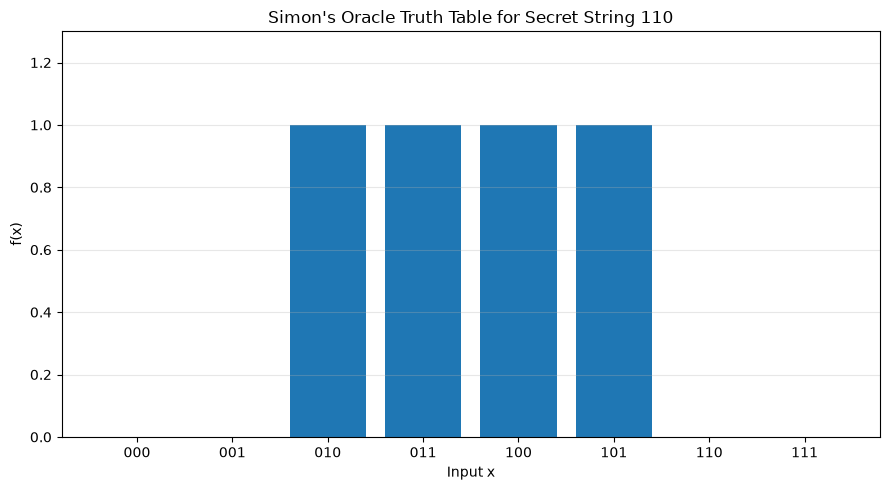

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

secret = "110"
n = len(secret)

def oracle_function(x):
    return int(x[0]) ^ int(x[1])

print("\nSIMON'S ORACLE FOR SECRET STRING 110")
print("=" * 60)

print("\nTruth Table")
print("-" * 60)
print("Input x   f(x)   x XOR s   f(x XOR s)")
print("-" * 60)

valid = True
inputs = []

for i in range(2 ** n):
    x = format(i, f"0{n}b")
    x_value = int(x, 2)
    s_value = int(secret, 2)
    xor_value = x_value ^ s_value
    x_xor_s = format(xor_value, f"0{n}b")

    fx = oracle_function(x)
    fx_xor_s = oracle_function(x_xor_s)

    if fx != fx_xor_s:
        valid = False

    inputs.append(x)
    print(f"{x:>7}   {fx:>3}   {x_xor_s:>7}   {fx_xor_s:>9}")

print("-" * 60)

if valid:
    print("Oracle verification: PASSED")
    print("f(x) = f(x XOR 110) for all inputs.")
else:
    print("Oracle verification: FAILED")

qc = QuantumCircuit(4, 3)

qc.h(0)
qc.h(1)
qc.h(2)

qc.cx(0, 3)
qc.cx(1, 3)

qc.h(0)
qc.h(1)
qc.h(2)

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

print("\nSIMON ORACLE CIRCUIT")
print("=" * 60)
print(qc.draw())

values = [oracle_function(x) for x in inputs]

plt.figure(figsize=(9, 5))
plt.bar(inputs, values)
plt.xlabel("Input x")
plt.ylabel("f(x)")
plt.title("Simon's Oracle Truth Table for Secret String 110")
plt.ylim(0, 1.3)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()